# Notebook 01: Data Understanding
Initial data exploration and understanding of the accident dataset

## Cell 1 — Imports

In [1]:
import sys
from pathlib import Path
from pathlib import Path

Path.cwd() # Check current working directory
# Add src/ to system path
sys.path.append(str(Path().resolve().parent))
import pandas as pd
from src.data.data_loader import (
    load_config,
    load_dataset,
    sample_dataset,
    dataset_overview
)

## Cell 2 — Load Config

In [2]:
config = load_config()
config

{'project': {'name': 'AccidentXAI', 'random_state': 42},
 'paths': {'raw_data': 'data/raw/US_Accidents_March23.csv',
  'processed_data': 'data/processed/processed_accidents.csv'},
 'target': {'column': 'Severity'},
 'temporal': {'date_column': 'Start_Time',
  'train_end_year': 2021,
  'test_year': 2022},
 'sampling': {'enabled': True, 'sample_size': 100000},
 'missing_values': {'numerical_strategy': 'median',
  'categorical_strategy': 'most_frequent'},
 'smote': {'enabled': True, 'random_state': 42},
 'cross_validation': {'folds': 5},
 'models': {'logistic_regression': True,
  'random_forest': True,
  'xgboost': True,
  'lightgbm': True,
  'catboost': True},
 'evaluation': {'scoring': ['f1_macro',
   'f1_weighted',
   'precision_weighted',
   'recall_weighted',
   'roc_auc_ovr']},
 'shap': {'sample_size': 2000}}

## Cell 3 — Load Dataset

In [3]:
df = load_dataset(config)
df.head()


Loading dataset from:
/Users/nurnafisfuad/Desktop/AccidentXAI/data/raw/US_Accidents_March23.csv


Dataset loaded successfully.



,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


## Cell 4 — Sample Dataset

In [4]:
df = sample_dataset(df, config)
df.shape


Sampling 100000 rows...



(100000, 46)

## Cell 5 — Dataset Overview

In [5]:
dataset_overview(df)

DATASET OVERVIEW

Shape: (100000, 46)

Columns:

['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Missing Values:

End_Lat              43988
End_Lng              43988
Precipitation(in)    28622
Wind_Chill(F)        25933
Wind_Speed(mph)       7443
Wind_Direction        2311
Visibility(mi)        2262
Humidity(%)           2259
Weather_Condition     2216
Temperature(F)        2120
Pressure(in) 

## Cell 6 — Missing Values

In [6]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)
missing_values.head(20)

End_Lat                  43988
End_Lng                  43988
Precipitation(in)        28622
Wind_Chill(F)            25933
Wind_Speed(mph)           7443
Wind_Direction            2311
Visibility(mi)            2262
Humidity(%)               2259
Weather_Condition         2216
Temperature(F)            2120
Pressure(in)              1817
Weather_Timestamp         1576
Nautical_Twilight          326
Civil_Twilight             326
Sunrise_Sunset             326
Astronomical_Twilight      326
Airport_Code               302
Street                     170
Timezone                   100
Zipcode                     21
dtype: int64

## Cell 7 — Severity Distribution

In [7]:
df["Severity"].value_counts()

Severity
2    79595
3    16849
4     2717
1      839
Name: count, dtype: int64

## Cell 8 — Severity Visualization

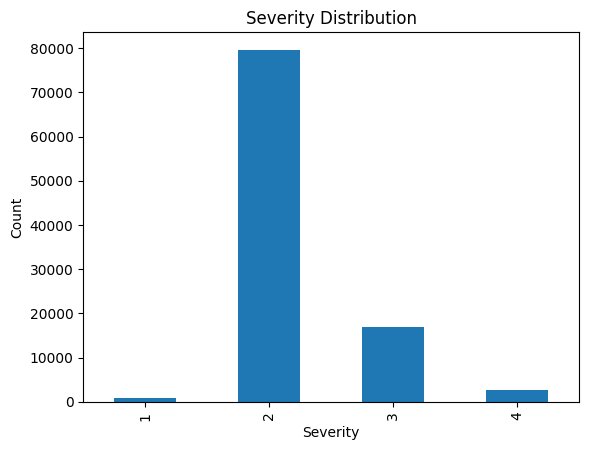

In [8]:
import matplotlib.pyplot as plt
df["Severity"].value_counts().sort_index().plot(
    kind="bar"
)
plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

## Cell 9 — Temporal Distribution

In [9]:
df["Start_Time"] = pd.to_datetime(
    df["Start_Time"],
    errors="coerce"
)
df["Year"] = df["Start_Time"].dt.year
df["Year"].value_counts().sort_index()

Year
2016.0     5370
2017.0     9284
2018.0    11493
2019.0    12257
2020.0    15071
2021.0    18493
2022.0    16344
2023.0     2039
Name: count, dtype: int64

## Cell 10 — Temporal Visualization

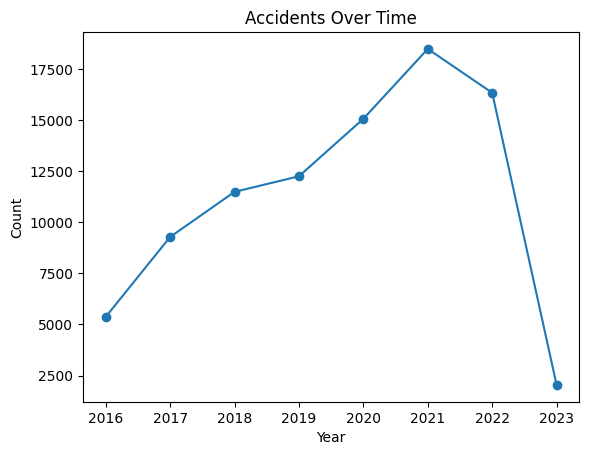

In [10]:
df["Year"].value_counts().sort_index().plot(
    kind="line",
    marker="o"
)
plt.title("Accidents Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()